# NYC For-Hire Vehicle (Uber/Lyft) Rides Analysis with DuckDB

Analyzes NYC For-Hire Vehicle (Uber/Lyft) trip data from the [NYC TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). Everything streams over HTTP — nothing saved to disk.

**Steps:** Stream Parquet → DuckDB analysis → Choropleth maps with GeoPandas

## 0. Install dependencies

In [ ]:
%pip install duckdb pandas geopandas matplotlib mapclassify --quiet

## 1. Imports & configuration

In [18]:
import duckdb
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import urllib.request, zipfile, io, os, tempfile, shutil

# ── Settings ────────────────────────────────────────────────────
# range(5, 8) = May-July 2023.  Change to range(1, 13) for full year.
MONTHS    = range(5,8)
YEAR      = 2023
MIN_RIDES = 100  # zones with fewer rides are shown as grey

TLC_BASE        = 'https://d37ci6vzurychx.cloudfront.net/trip-data'
ZONE_LOOKUP_URL = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv'
SHAPEFILE_URL   = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip'

print('OK')

OK


## 2. Build Parquet URL list

The NYC TLC publishes one Parquet file per month. DuckDB reads a list of URLs in a single query, streaming only the columns we SELECT (Parquet is columnar — much faster than downloading full files). All of the data can be downloaded from the [NYC TLC website](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).

In [19]:
urls = [
    f'{TLC_BASE}/fhvhv_tripdata_{YEAR}-{str(m).zfill(2)}.parquet'
    for m in MONTHS
]
for u in urls:
    print(u)


https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2023-05.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2023-06.parquet
https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2023-07.parquet


## 3. Load data into DuckDB

In [20]:
con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')

# Build a SQL-safe list of quoted URLs to inline into read_parquet()
urls_sql = '[' + ', '.join(f"'{u}'" for u in urls) + ']'

print('Loading rides... (~30-60s per month, only selected columns are downloaded)')
con.execute(f"""
    CREATE OR REPLACE TABLE rides AS
    SELECT
        hvfhs_license_num,
        PULocationID,
        DOLocationID,
        base_passenger_fare,
        trip_miles
    FROM read_parquet({urls_sql})
    WHERE trip_miles > 0
      AND base_passenger_fare > 0
""")

count = con.execute('SELECT COUNT(*) FROM rides').fetchone()[0]
print(f'Loaded {count:,} rides')

Loading rides... (~30-60s per month, only selected columns are downloaded)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 58,324,013 rides


## 4. Peek at the data

In [21]:
con.execute('SELECT * FROM rides LIMIT 5').df()

,hvfhs_license_num,PULocationID,DOLocationID,base_passenger_fare,trip_miles
0,HV0005,32,81,12.30,2.247
1,HV0005,81,254,8.85,1.826
2,HV0003,121,92,12.70,3.880
3,HV0003,92,53,11.59,2.310
4,HV0003,53,122,27.69,9.450


In [22]:
con.execute("""
    SELECT
        hvfhs_license_num AS license,
        CASE hvfhs_license_num
            WHEN 'HV0003' THEN 'Uber'
            WHEN 'HV0005' THEN 'Lyft'
            ELSE 'Other'
        END AS provider,
        COUNT(*) AS num_rides,
        ROUND(AVG(base_passenger_fare / trip_miles), 2) AS avg_fare_per_mile
    FROM rides
    GROUP BY ALL
    ORDER BY num_rides DESC
""").df()

,license,provider,num_rides,avg_fare_per_mile
0,HV0003,Uber,41801379,7.24
1,HV0005,Lyft,16522634,6.29


## 5. Average fare per mile by pickup zone

Join against the TLC zone lookup CSV (read directly from URL) to get zone names, and null-out any zone with fewer than `MIN_RIDES` rides.

In [ ]:
# This runs a SQL query directly from Python using DuckDB (the `con` object).
# The f""" ... """ is an f-string — it lets us inject Python variables (like MIN_RIDES)
# straight into the SQL text before it runs.

df_fare = con.execute(f"""
    SELECT
        PULocationID AS pickup_zone,   -- Rename the column to something clearer
        "Zone",                        -- The human-readable zone name (e.g. "JFK Airport")
        
        -- If a zone has fewer than {MIN_RIDES} rides, return NULL instead of the fare.
        -- This prevents misleading averages from zones with barely any data.
        IF(num_rides >= {MIN_RIDES}, fare_per_mile, NULL) AS fare_per_mile,
        num_rides

    -- Everything below is a SUBQUERY — think of it as a temporary table
    -- called "rides" that the outer SELECT reads from.
    FROM (
        SELECT
            PULocationID,                              -- The pickup zone ID
            AVG(base_passenger_fare / trip_miles) AS fare_per_mile,  -- Average $ per mile for each pickup zone
            COUNT(*) AS num_rides                      -- How many rides started in this zone
        FROM rides
        WHERE DOLocationID < 264                       -- Drop invalid/unknown drop-off locations (264+ are not real zones)
        GROUP BY PULocationID                          -- One summary row per pickup zone
    ) rides   -- We name this subquery "rides" so the outer SELECT can reference it

    -- JOIN attaches zone name labels to our numeric zone IDs.
    -- We're reading the lookup table directly from a URL — DuckDB can do this natively.
    JOIN (
        SELECT LocationId, "Zone"
        FROM '{ZONE_LOOKUP_URL}'       -- Python variable injected here — points to a CSV/Parquet file online
    ) zones ON (LocationId = PULocationID)   -- Match: zone lookup ID == our pickup zone ID

    ORDER BY fare_per_mile DESC NULLS LAST   -- Highest fare-per-mile first; NULLs go to the bottom

""").df()   # .df() converts the DuckDB result into a pandas DataFrame

# ── Quick sanity check ───────────────────────────────────────────────
# notna().sum() counts how many zones have a real fare value (not NULL)
# This tells us: out of all zones, how many had enough rides to trust?
print(f"Zones with data: {df_fare['fare_per_mile'].notna().sum()} / {len(df_fare)}")

df_fare.head(10)  # Preview the top 10 highest fare-per-mile pickup zones

Zones with data: 259 / 262


,pickup_zone,Zone,fare_per_mile,num_rides
0,161,Midtown Center,10.650870,684792
1,237,Upper East Side South,10.042834,456460
2,163,Midtown North,10.038933,487415
3,211,SoHo,9.984551,331983
4,230,Times Sq/Theatre District,9.828728,672836
5,158,Meatpacking/West Village West,9.683761,356551
6,100,Garment District,9.648623,332123
7,2,Jamaica Bay,9.507523,152
8,246,West Chelsea/Hudson Yards,9.415198,619551
9,234,Union Sq,9.344963,591623


In [24]:
# calculate % of rides
df_fare['pct_of_total'] = (df_fare['num_rides'] / df_fare['num_rides'].sum() * 100).round(2)

# sort the data in descending order of num_rides    
df_fare = df_fare.sort_values(by='num_rides', ascending=False)

df_fare.head(10)

,pickup_zone,Zone,fare_per_mile,num_rides,pct_of_total
245,138,LaGuardia Airport,4.842910,998725,1.79
257,132,JFK Airport,3.911548,923193,1.65
31,79,East Village,8.099377,770417,1.38
76,61,Crown Heights North,6.823242,759548,1.36
0,161,Midtown Center,10.650870,684792,1.23
4,230,Times Sq/Theatre District,9.828728,672836,1.20
23,231,TriBeCa/Civic Center,8.773265,642665,1.15
19,68,East Chelsea,9.039706,637417,1.14
79,37,Bushwick South,6.801640,628584,1.13
8,246,West Chelsea/Hudson Yards,9.415198,619551,1.11


## 6. Uber vs. Lyft — fare per mile by zone

In [25]:
# Uber (HV0003)
con.execute("""
    CREATE OR REPLACE TABLE uber_rides AS
    SELECT PULocationID,
           AVG(base_passenger_fare / trip_miles) AS fpm_uber,
           COUNT(*) AS cnt_uber
    FROM rides
    WHERE hvfhs_license_num = 'HV0003' AND DOLocationID < 264
    GROUP BY PULocationID
""")

# Lyft (HV0005)
con.execute("""
    CREATE OR REPLACE TABLE lyft_rides AS
    SELECT PULocationID,
           AVG(base_passenger_fare / trip_miles) AS fpm_lyft,
           COUNT(*) AS cnt_lyft
    FROM rides
    WHERE hvfhs_license_num = 'HV0005' AND DOLocationID < 264
    GROUP BY PULocationID
""")

df_diff = con.execute(f"""
    SELECT
        uber.PULocationID AS pickup_zone,
        cnt_uber, cnt_lyft,
        ROUND(fpm_uber, 2) AS fpm_uber,
        ROUND(fpm_lyft, 2) AS fpm_lyft,
        IF(cnt_uber >= {MIN_RIDES} AND cnt_lyft >= {MIN_RIDES},
           ROUND(fpm_uber - fpm_lyft, 2), NULL) AS uber_minus_lyft
    FROM uber_rides uber
    JOIN lyft_rides lyft ON (uber.PULocationID = lyft.PULocationID)
    ORDER BY uber_minus_lyft DESC NULLS LAST
""").df()

df_diff.head(10)

,pickup_zone,cnt_uber,cnt_lyft,fpm_uber,fpm_lyft,uber_minus_lyft
0,237,366318,90142,10.69,7.42,3.27
1,163,383710,103705,10.74,7.46,3.27
2,161,550798,133994,11.27,8.09,3.18
3,230,520197,152639,10.49,7.57,2.92
4,236,324863,90413,9.28,6.62,2.67
5,158,273549,83002,10.30,7.66,2.64
6,100,250510,81613,10.28,7.70,2.58
7,211,260998,70985,10.51,8.04,2.48
8,162,356319,99752,9.78,7.38,2.40
9,231,493505,149160,9.31,6.98,2.33


## 7. Download NYC taxi zone shapefile

Stream the ZIP into memory, extract to a temp dir, load with GeoPandas, then clean up.

In [ ]:
print('Downloading shapefile...')

# A shapefile is a common GIS format that stores geographic shapes (like zone boundaries).
# It lives online as a .zip file, so we need to download and unzip it before we can use it.

# urllib.request.urlopen() opens a connection to the URL, just like a browser would.
# The `with` block ensures the connection is automatically closed when we're done.
with urllib.request.urlopen(SHAPEFILE_URL) as resp:
    zip_bytes = resp.read()   # Read the entire file into memory as raw bytes (it's a zip file)

# Create a temporary folder on disk to unzip into.
# tempfile.mkdtemp() picks a safe, unique location automatically (e.g. /tmp/abc123/)
tmpdir = tempfile.mkdtemp()

# io.BytesIO() wraps the raw bytes so zipfile can treat them like a file on disk
# z.extractall() dumps all the files inside the zip into our temp folder
with zipfile.ZipFile(io.BytesIO(zip_bytes)) as z:
    z.extractall(tmpdir)

# A shapefile is actually several files (.shp, .dbf, .prj, etc.) — we only need the .shp
# os.walk() recursively searches every folder and file inside tmpdir
# `next(... for ... if ...)` is a generator expression — it stops as soon as it finds the first match
shp_path = next(
    os.path.join(root, f)          # Build the full file path
    for root, dirs, files in os.walk(tmpdir)   # Walk through every subfolder
    for f in files                 # Look at every file
    if f.endswith('.shp')          # Stop when we find the shapefile
)

# GeoPandas reads the shapefile into a GeoDataFrame —
# like a regular pandas DataFrame but with an extra 'geometry' column
# that holds the actual shape (polygon) for each taxi zone
gdf = gpd.read_file(shp_path)

# We're done with the temp folder — delete it to keep things clean
shutil.rmtree(tmpdir)

# Rename the zone ID column to match the name used in our other DataFrames
# so we can join them together later
gdf = gdf.rename(columns={'LocationID': 'pickup_zone'})

# Make sure the zone ID is stored as an integer, not a string — avoids silent join failures
gdf['pickup_zone'] = gdf['pickup_zone'].astype(int)

# A CRS (Coordinate Reference System) defines how lat/lon maps to actual locations on Earth.
# EPSG:2263 is "NY State Plane" — it measures distances in feet and is optimised for NYC.
# This matters when calculating areas, distances, or drawing accurate maps.
gdf = gdf.to_crs('EPSG:2263')

print(f'Loaded {len(gdf)} taxi zones')
gdf.head(3)

Loaded 263 taxi zones


,OBJECTID,Shape_Leng,Shape_Area,zone,pickup_zone,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."


## 8. Merge results with geodata

In [ ]:
# We need to combine two things:
#   - gdf      → the geometry (shapes) for every NYC taxi zone
#   - df_fare  → the fare-per-mile stats we calculated earlier
#
# .merge() works like a SQL JOIN — it matches rows from both tables using a shared column.
# on='pickup_zone'  → the column to match on (must exist in both DataFrames)
# how='left'        → keep ALL zones from gdf, even if df_fare has no data for that zone
#                     (those zones will get NaN for fare_per_mile instead of disappearing)

gdf_fare = (
    gdf
    .merge(
        df_fare[['pickup_zone', 'fare_per_mile']],  # Only bring in these 2 columns from df_fare — no need to drag everything across
        on='pickup_zone',
        how='left'
    )
)

# Same pattern, but now we're attaching the Uber-vs-Lyft price difference
# to the zone shapes instead of fare-per-mile
gdf_diff = (
    gdf
    .merge(
        df_diff[['pickup_zone', 'uber_minus_lyft']],  # Only the columns we need from df_diff
        on='pickup_zone',
        how='left'
    )
)

# Sanity checks — tells us how many zones actually have data to display on the map.
# If this number is much lower than the total zones, something likely went wrong in the join
# (e.g. mismatched data types on pickup_zone — hence the .astype(int) we did earlier)
print('fare map — zones with data:', gdf_fare['fare_per_mile'].notna().sum())
print('diff map — zones with data:', gdf_diff['uber_minus_lyft'].notna().sum())

fare map — zones with data: 258
diff map — zones with data: 256


## 9. Map helper function

In [ ]:
# A reusable function that draws a choropleth map — a map where zones are
# coloured by a numeric value (e.g. darker = higher fare).
# 
# Parameters:
#   gdf       → GeoDataFrame containing zone shapes + the data column to colour by
#   column    → name of the column to visualise (e.g. 'fare_per_mile')
#   title     → text shown at the top of the map
#   cmap      → colour palette name (e.g. 'YlOrRd' for yellow→red, 'RdBu' for diverging)
#   label     → text shown next to the colour bar legend
#   vmin/vmax → optional: manually set the colour scale limits
#   diverging → if True, use a special scale centred on 0 (for data that goes +/-)

def choropleth(gdf, column, title, cmap, label, vmin=None, vmax=None, diverging=False):

    # Create the canvas: fig is the whole image, ax is the area we draw the map on
    fig, ax = plt.subplots(figsize=(13, 11))

    # Set background colours — the light grey behind the map and the off-white page behind that
    ax.set_facecolor('#e0e0e0')
    fig.patch.set_facecolor('#f7f7f7')

    # Draw ALL zones first in flat grey — this ensures zones with no data
    # still appear on the map as a visible grey shape rather than just disappearing
    gdf.plot(ax=ax, color='#c8c8c8', edgecolor='white', linewidth=0.3)

    # Drop zones that have no value for this column — we can't colour what we don't have
    data = gdf.dropna(subset=[column])

    if diverging:
        # Diverging scale: used when your data has meaningful positive AND negative values
        # and 0 is a special midpoint (e.g. Uber cheaper ←→ Lyft cheaper)
        # We make the scale symmetrical around 0 so the midpoint colour always = 0

        # Find the furthest value from 0 in either direction
        abs_max = max(abs(data[column].min()), abs(data[column].max()))

        # Use provided limits if given, otherwise use the symmetric range we just calculated
        v0 = vmin if vmin is not None else -abs_max
        v1 = vmax if vmax is not None else abs_max

        # TwoSlopeNorm forces the colour midpoint to sit exactly at 0,
        # even if there are more positive values than negative ones
        norm = mcolors.TwoSlopeNorm(vmin=v0, vcenter=0, vmax=v1)

        data.plot(column=column, ax=ax, cmap=cmap, norm=norm, edgecolor='white', linewidth=0.3)

        # ScalarMappable is required by matplotlib to draw the colour bar legend
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

    else:
        # Standard (sequential) scale: used when all values run in one direction
        # (e.g. $0 → high fare, where there's no meaningful midpoint)

        # Default to the 2nd–98th percentile range to avoid a single extreme outlier
        # squashing all the other colours into a tiny band
        v0 = vmin if vmin is not None else data[column].quantile(0.02)
        v1 = vmax if vmax is not None else data[column].quantile(0.98)

        data.plot(column=column, ax=ax, cmap=cmap, vmin=v0, vmax=v1, edgecolor='white', linewidth=0.3)

        # Normalize maps the data range onto the 0→1 scale that the colour palette expects
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=v0, vmax=v1))

    # matplotlib requires this line before drawing the colour bar — it's just boilerplate
    sm.set_array([])

    # Add the colour bar legend on the side of the map
    # fraction controls its width, pad controls the gap between map and bar
    cbar = fig.colorbar(sm, ax=ax, fraction=0.028, pad=0.02)
    cbar.set_label(label, fontsize=11)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.axis('off')       # Hide the lat/lon axis ticks — they clutter a map
    plt.tight_layout()   # Automatically adjust spacing so nothing gets clipped
    plt.show()

## 10. Map: Average fare per mile by zone

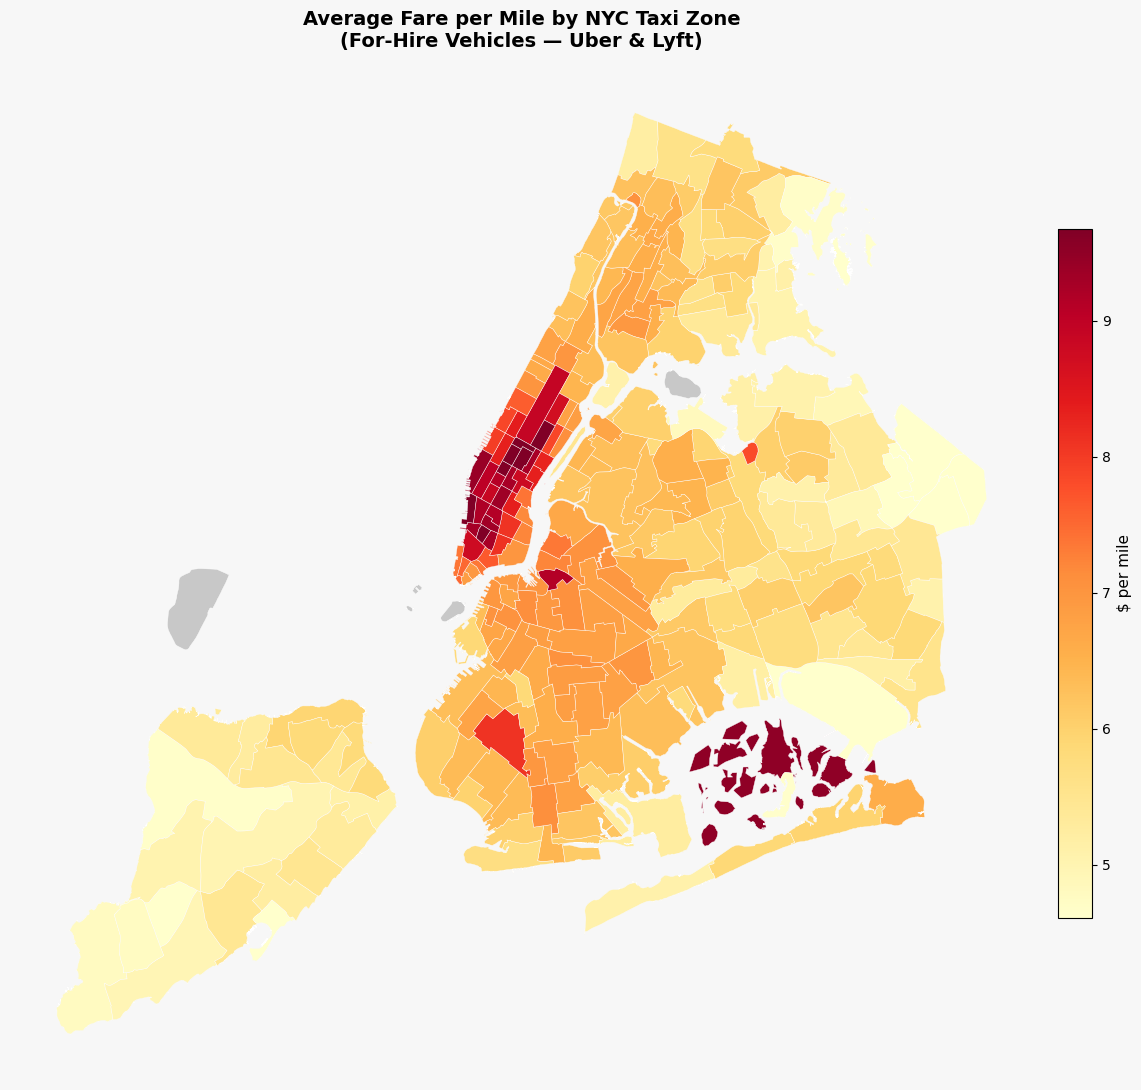

In [29]:
choropleth(
    gdf_fare,
    column='fare_per_mile',
    title='Average Fare per Mile by NYC Taxi Zone\n(For-Hire Vehicles — Uber & Lyft)',
    cmap='YlOrRd',
    label='$ per mile',
)

## 11. Map: Uber vs. Lyft fare difference

🔴 **Red** = Uber more expensive  
🔵 **Blue** = Lyft more expensive  
⬜ **Grey** = fewer than 100 rides

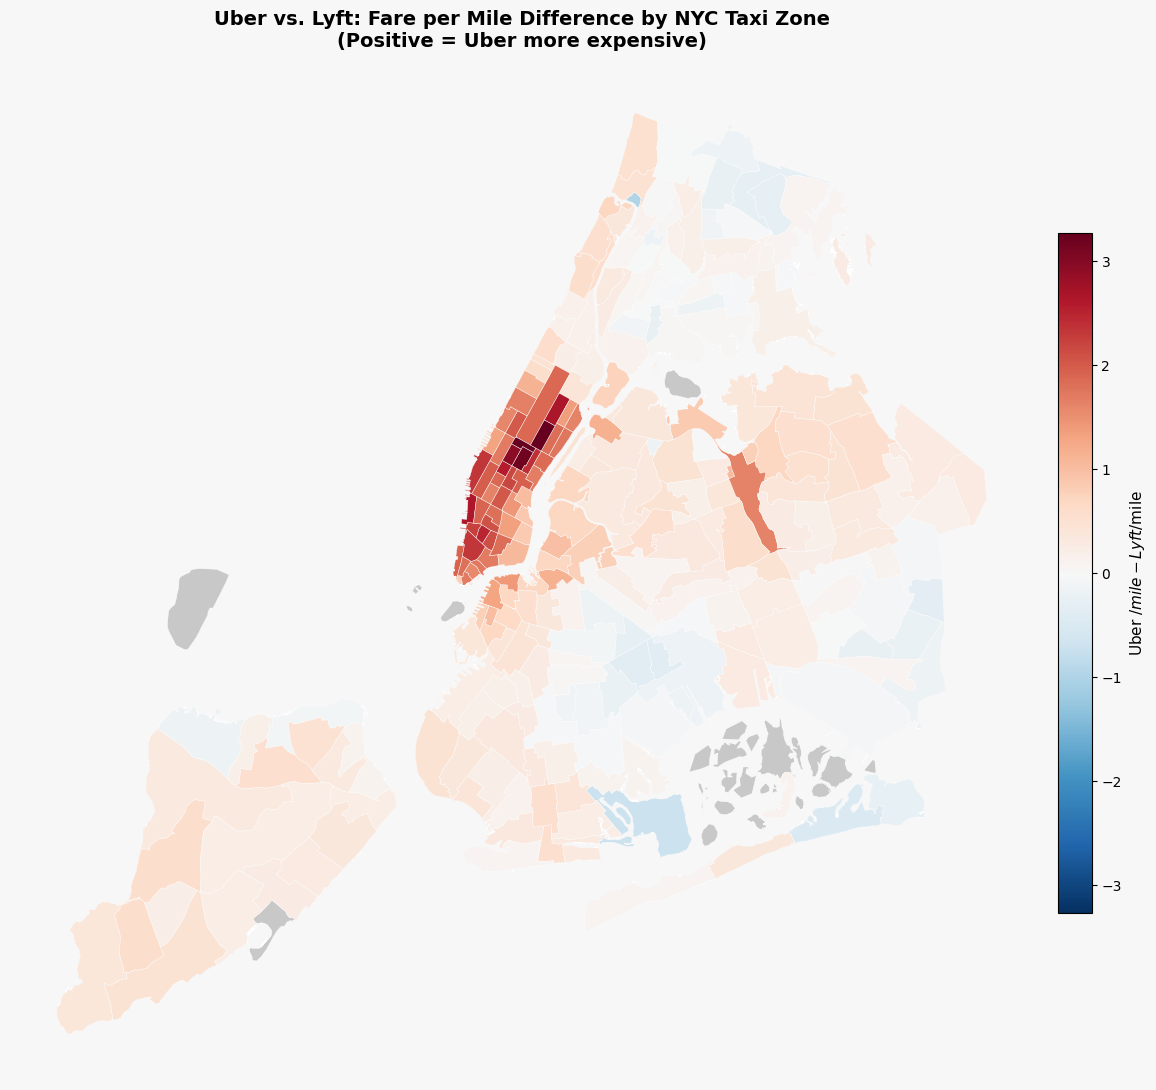

In [30]:
choropleth(
    gdf_diff,
    column='uber_minus_lyft',
    title='Uber vs. Lyft: Fare per Mile Difference by NYC Taxi Zone\n(Positive = Uber more expensive)',
    cmap='RdBu_r',
    label='Uber $/mile - Lyft $/mile',
    diverging=True,
)

In [ ]:
can we add a section on using the map, to show distance of rides by starting point?

## 12. Bar charts: top & bottom zones by fare per mile

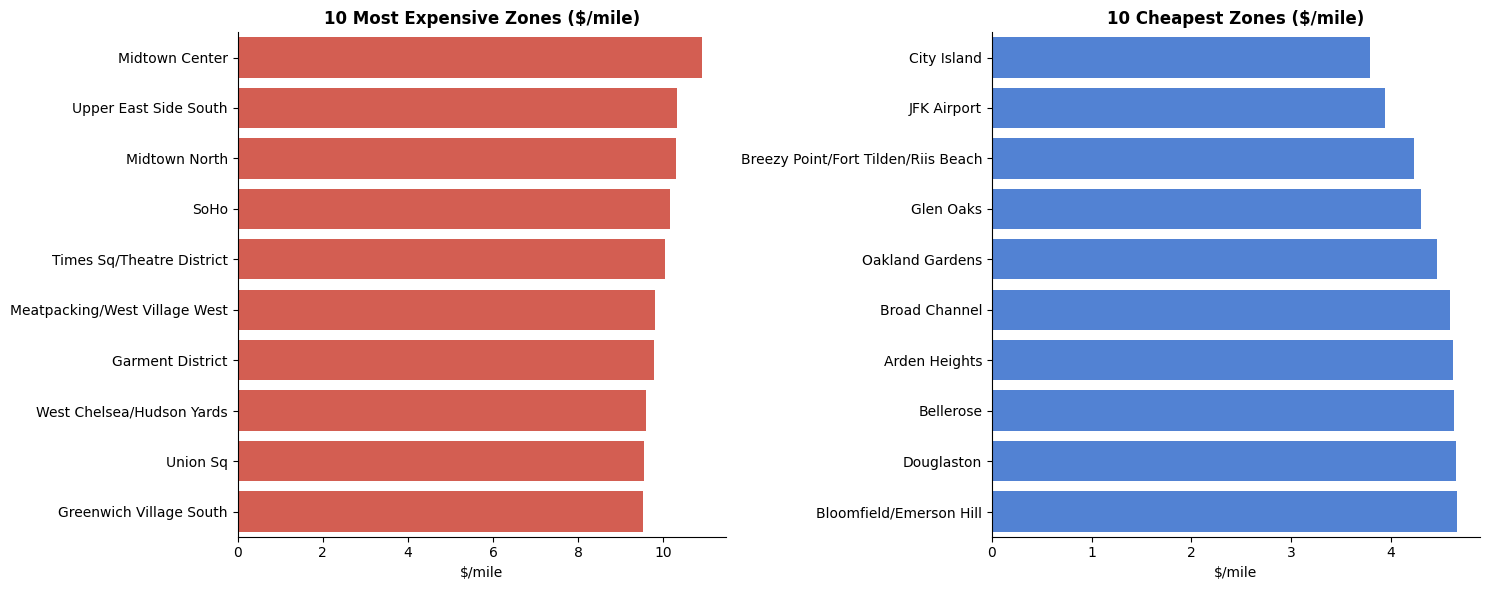

In [15]:
import seaborn as sns

top10 = df_fare.dropna(subset=['fare_per_mile']).nlargest(10, 'fare_per_mile').sort_values('fare_per_mile', ascending=False) 
bot10 = df_fare.dropna(subset=['fare_per_mile']).nsmallest(10, 'fare_per_mile').sort_values('fare_per_mile')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=top10, x='fare_per_mile', y='Zone', color='#e84d3d', ax=axes[0])
axes[0].set_title('10 Most Expensive Zones ($/mile)', fontweight='bold')
axes[0].set_xlabel('$/mile')
axes[0].set_ylabel('')

sns.barplot(data=bot10, x='fare_per_mile', y='Zone', color='#3d7de8', ax=axes[1])
axes[1].set_title('10 Cheapest Zones ($/mile)', fontweight='bold')
axes[1].set_xlabel('$/mile')
axes[1].set_ylabel('')

sns.despine(ax=axes[0])
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## 14. Average trip distance by pickup zone — Uber vs. Lyft

In [16]:
df_distance = con.execute(f"""
    SELECT
        provider,
        PULocationID AS pickup_zone,
        \"Zone\",
        ROUND(AVG(trip_miles), 2) AS avg_trip_miles,
        COUNT(*) AS num_rides
    FROM (
        SELECT
            CASE hvfhs_license_num
                WHEN 'HV0003' THEN 'Uber'
                WHEN 'HV0005' THEN 'Lyft'
            END AS provider,
            PULocationID,
            trip_miles
        FROM rides
        WHERE hvfhs_license_num IN ('HV0003', 'HV0005')
          AND DOLocationID < 264
    ) r
    JOIN (
        SELECT LocationId, \"Zone\"
        FROM '{ZONE_LOOKUP_URL}'
    ) zones ON (LocationId = PULocationID)
    GROUP BY provider, PULocationID, \"Zone\"
    HAVING COUNT(*) >= {MIN_RIDES}
""").df()

print(df_distance.groupby('provider')[['avg_trip_miles','num_rides']].mean().round(2))
df_distance.head()

          avg_trip_miles  num_rides
provider                           
Lyft                4.73   41284.87
Uber                4.67  104778.84


,provider,pickup_zone,Zone,avg_trip_miles,num_rides
0,Lyft,192,Queensboro Hill,5.02,15195
1,Uber,50,Clinton West,4.29,166419
2,Uber,133,Kensington,4.33,54173
3,Lyft,195,Red Hook,5.32,25911
4,Uber,262,Yorkville East,4.62,104593


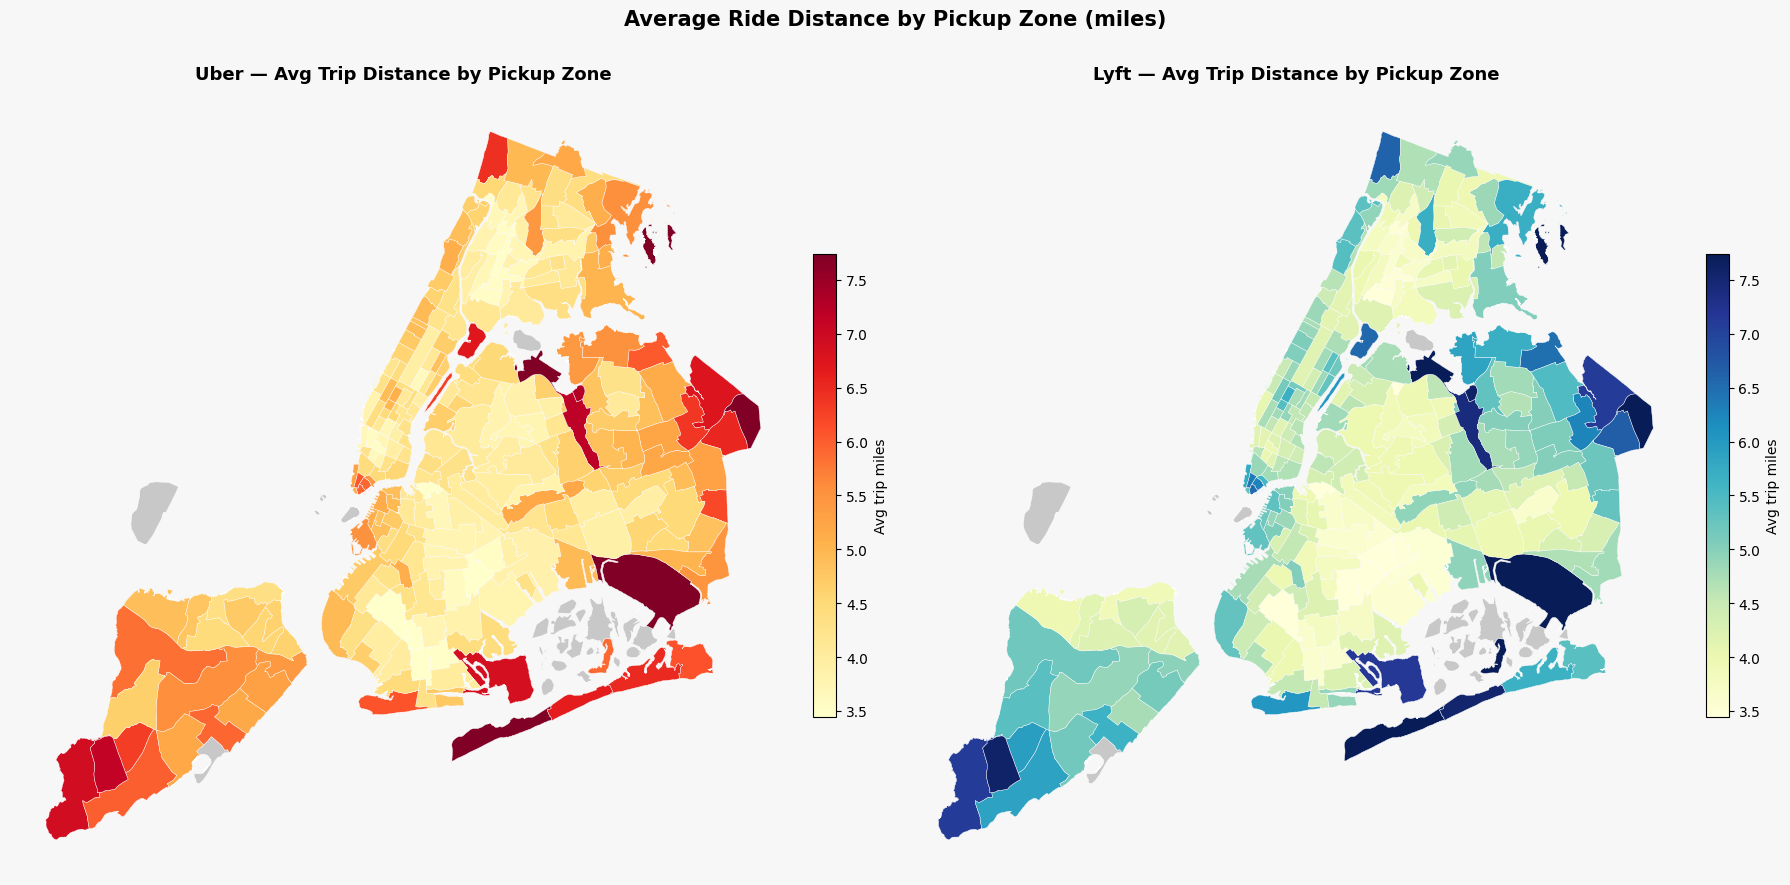

In [17]:
# Split into one df per provider and merge with geodata
uber_dist = df_distance[df_distance['provider'] == 'Uber'][['pickup_zone','avg_trip_miles']]
lyft_dist = df_distance[df_distance['provider'] == 'Lyft'][['pickup_zone','avg_trip_miles']]

gdf_uber = gdf.merge(uber_dist, on='pickup_zone', how='left')
gdf_lyft = gdf.merge(lyft_dist, on='pickup_zone', how='left')

# Shared colour scale so both maps are directly comparable
vmin = df_distance['avg_trip_miles'].quantile(0.02)
vmax = df_distance['avg_trip_miles'].quantile(0.98)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#f7f7f7')

for ax, gdf_plot, title, color in [
    (axes[0], gdf_uber, 'Uber — Avg Trip Distance by Pickup Zone', 'YlOrRd'),
    (axes[1], gdf_lyft, 'Lyft — Avg Trip Distance by Pickup Zone', 'YlGnBu'),
]:
    ax.set_facecolor('#e0e0e0')
    # grey base for zones with no data
    gdf_plot.plot(ax=ax, color='#c8c8c8', edgecolor='white', linewidth=0.3)
    # colour zones with data
    gdf_plot.dropna(subset=['avg_trip_miles']).plot(
        column='avg_trip_miles', ax=ax,
        cmap=color, vmin=vmin, vmax=vmax,
        edgecolor='white', linewidth=0.3
    )
    sm = plt.cm.ScalarMappable(
        cmap=color, norm=plt.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.028, pad=0.02)
    cbar.set_label('Avg trip miles', fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.axis('off')

plt.suptitle('Average Ride Distance by Pickup Zone (miles)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()